In [19]:
# loads s3m MBA, plots orbital elements, 5 panel plot for d vs ddot
# tests for sample MBA 2019 NC114 https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=2019%20NC114
# according to JPL Horizons for Sept. 23 2025 00:00, APmag = 21.563, RA = 359.97881, Dec = -0.07536, dra = -28.6641, ddec = -12.0246
# d = 1.71970376041569, ddot = 3.1089344

In [2]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoom as no
import S3Marray as sm
import importlib
from functools import reduce
importlib.reload(sm)

<module 'S3Marray' from '/astro/users/ds2004/digest3/S3Marray.py'>

In [4]:
from astroquery.imcce import Skybot
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u
field = SkyCoord(0*u.deg, 0*u.deg)
epoch = Time('2025-09-23 00:00', format='iso')
Skybot.cone_search(field, 5*u.arcmin, epoch)


Number,Name,RA,DEC,Type,V,posunc,centerdist,RA_rate,DEC_rate,geodist,heliodist,alpha,elong,x,y,z,vx,vy,vz,epoch
,,deg,deg,,mag,arcsec,arcsec,arcsec / h,arcsec / h,AU,AU,deg,deg,AU,AU,AU,AU / d,AU / d,AU / d,d
int64,str10,float64,float64,str8,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
--,2019 NC114,359.9844545833333,-0.07309388888888889,MB>Outer,21.6,38.118,269.024,-28.2474,-12.025,1.71976855688,2.71954272873,0.03,179.9,2.720650001,-0.017464295,-0.009629809,0.001822749,0.010078593,0.004411208,2460940.0


In [5]:
s3m = sm.define_s3m()
s3m,array4D, H_center, a_center, e_center, i_center = sm.s3m_array(s3m)

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [6]:
s3m.columns

Index(['OID', 'FORMAT', 'q', 'e', 'i', 'node', 'argperi', 't_p', 'H', 't_0',
       'INDEX', 'N_PAR', 'MOID', 'COMPCODE', 'a'],
      dtype='object')

In [7]:
# defining the min/max values for a,e,i,H
node_min = s3m["node"].min()
node_max = s3m["node"].max()
argperi_min = s3m["argperi"].min()
argperi_max = s3m["argperi"].max()
t_p_min = s3m["t_p"].min()
t_p_min = s3m["t_p"].max()

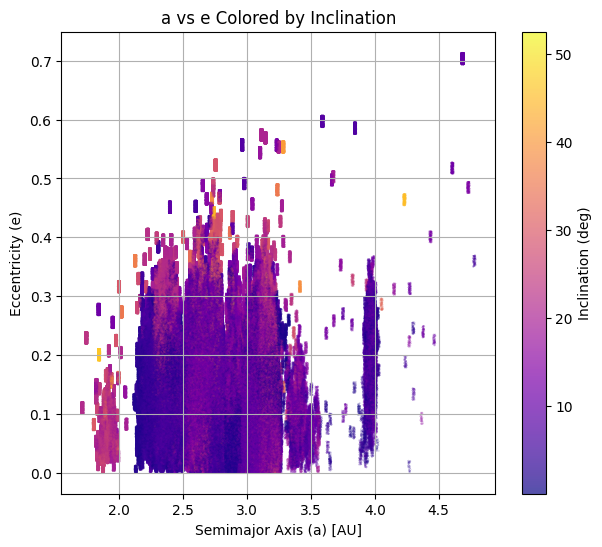

In [8]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(s3m["a"], s3m["e"], c=s3m["i"], cmap="plasma", s=0.01, alpha=0.7)
plt.xlabel("Semimajor Axis (a) [AU]")
plt.ylabel("Eccentricity (e)")
plt.title("a vs e Colored by Inclination")
plt.colorbar(sc, label="Inclination (deg)")
plt.grid(True)
plt.show()

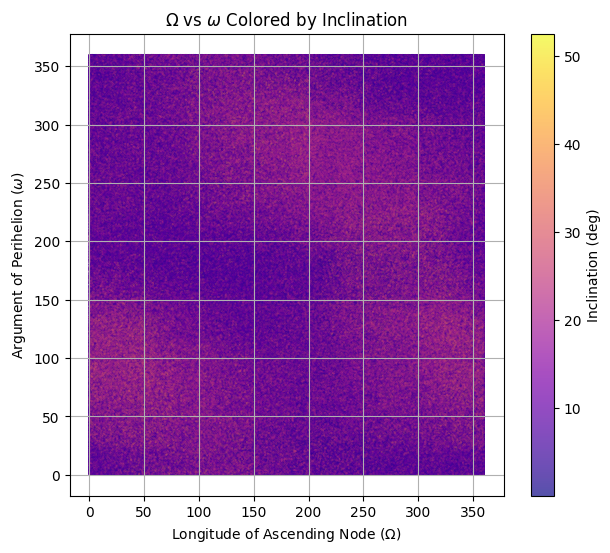

In [9]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(s3m["node"], s3m["argperi"], c=s3m["i"], cmap="plasma", s=0.01, alpha=0.7)
plt.xlabel("Longitude of Ascending Node ($\Omega$)")
plt.ylabel("Argument of Perihelion ($\omega$)")
plt.title("$\Omega$ vs $\omega$ Colored by Inclination")
plt.colorbar(sc, label="Inclination (deg)")
plt.grid(True)
plt.show()

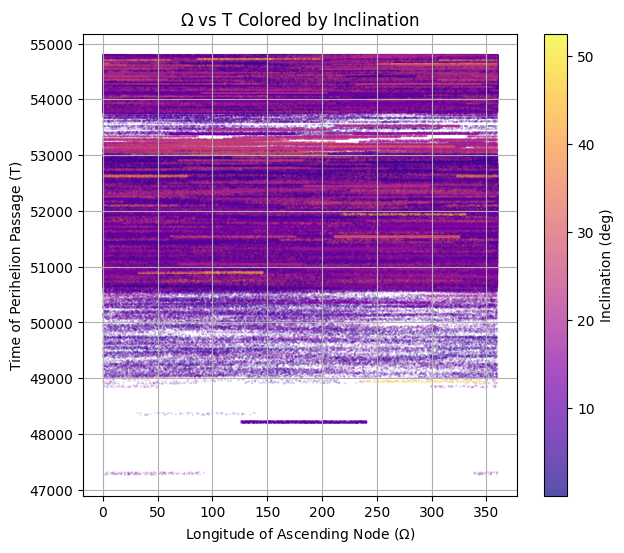

In [10]:

plt.figure(figsize=(7, 6))
sc = plt.scatter(s3m["node"], s3m["t_p"], c=s3m["i"], cmap="plasma", s=0.01, alpha=0.7)
plt.xlabel("Longitude of Ascending Node ($\Omega$)")
plt.ylabel("Time of Perihelion Passage (T)")
plt.title("$\Omega$ vs T Colored by Inclination")
plt.colorbar(sc, label="Inclination (deg)")
plt.grid(True)
plt.show()

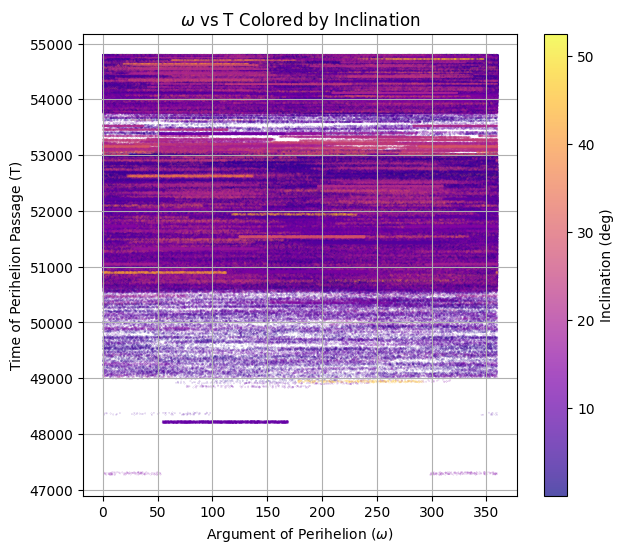

In [11]:
plt.figure(figsize=(7, 6))
sc = plt.scatter(s3m["argperi"], s3m["t_p"], c=s3m["i"], cmap="plasma", s=0.01, alpha=0.7)
plt.xlabel("Argument of Perihelion ($\omega$)")
plt.ylabel("Time of Perihelion Passage (T)")
plt.title("$\omega$ vs T Colored by Inclination")
plt.colorbar(sc, label="Inclination (deg)")
plt.grid(True)
plt.show()

In [20]:
obstime_str="2025-09-23T00:00:00"
ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 359.9, -0.07, -0.188316, -0.08016  # this is for the example MBA 2019 NC114
#ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 10.0, 20.0, 0.12, 0.22
# add mag here
#mag = 20.0
mag = 21.563
# anti-Sun at Sep 23 = equinox so RA = 0, Dec = 0
ra0_deg, dec0_deg = 0.0, 0.0

l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 

In [21]:
from matplotlib.colors import TwoSlopeNorm


d_vals = np.linspace(0.00, 4.00, 60)
v_vals = np.linspace(-20.0, 20.0, 120)

W = np.zeros((len(d_vals), len(v_vals)))
A = np.zeros_like(W)
E = np.zeros_like(W)
I = np.zeros_like(W)
H = np.zeros_like(W)


for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        w, a, e, inc, H_0 = nf.compute_neomod3_weight(
            d, v, l_hat, v_hat, mag, obstime, rE, vE, r_obs,
            array4D, H_center, a_center, e_center, i_center  
        )
        W[i, j] = w
        A[i, j] = a
        E[i, j] = e
        I[i, j] = inc
        H[i, j] = np.asarray(H_0).squeeze()


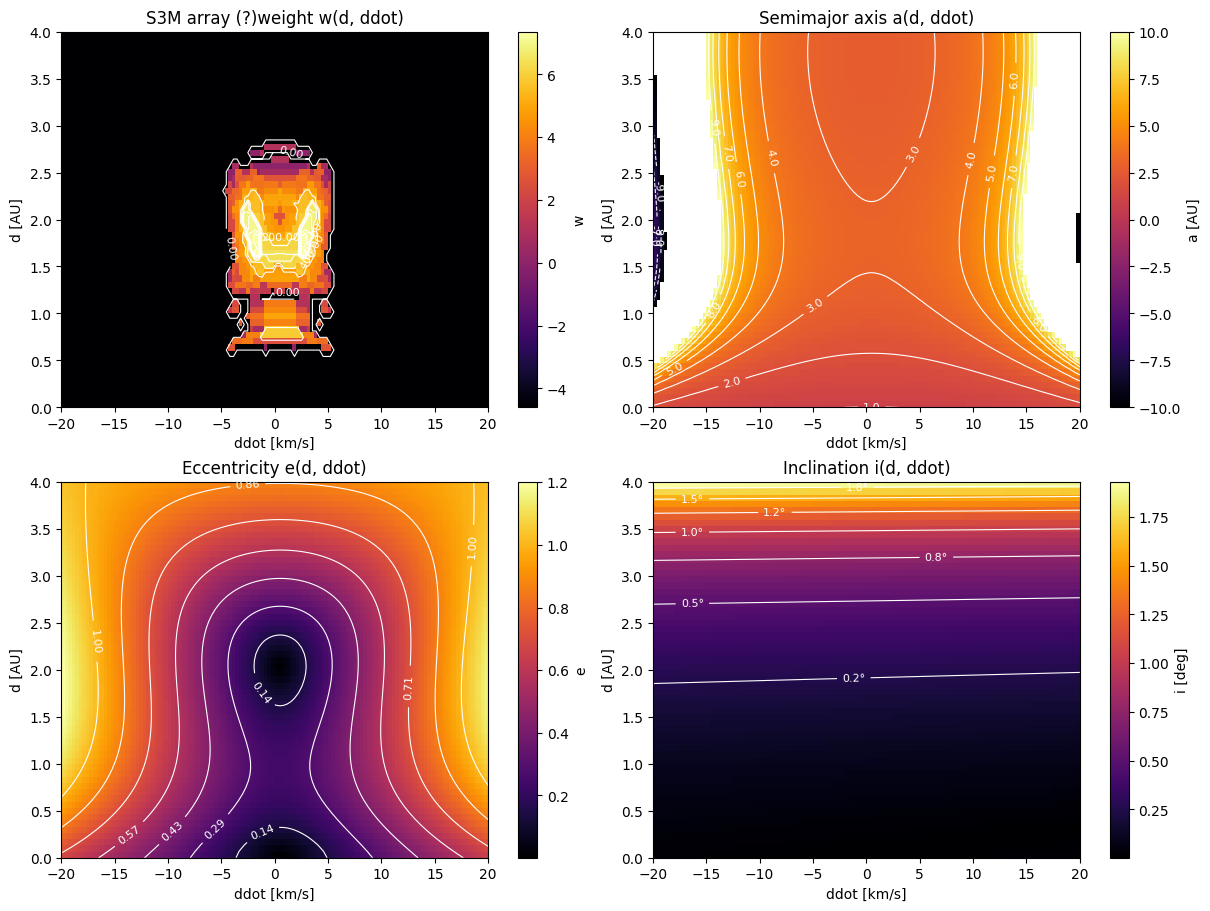

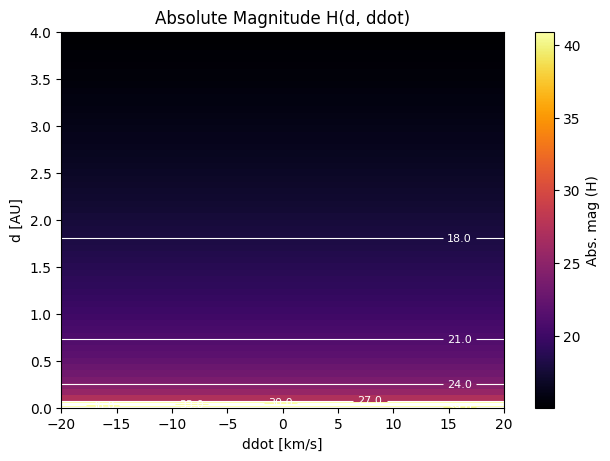

In [22]:
extent = [v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()]  # x=ddot, y=d
X, Y = np.meshgrid(v_vals, d_vals, indexing="xy")

fig, axs = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# weight
im0 = axs[0, 0].imshow(np.log(W + 1e-2), origin="lower", extent=extent, aspect="auto", cmap="inferno")
c0  = axs[0, 0].contour(X, Y, W, levels=8, colors="white", linewidths=0.8)
axs[0, 0].clabel(c0, inline=True, fontsize=8, fmt="%.2f")
axs[0, 0].set(title="S3M array (?)weight w(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im0, ax=axs[0, 0], label="w")

# semimajor axis
A_mask = np.ma.masked_where(~np.isfinite(A) | (np.abs(A) > 10), A)
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
im1 = axs[0, 1].imshow(A_mask, origin="lower", extent=extent, aspect="auto", cmap="inferno", norm=norm)
cs1 = axs[0, 1].contour(X, Y, A_mask, levels=np.linspace(-10, 10, 21), colors="white", linewidths=0.8)
axs[0, 1].clabel(cs1, inline=True, fontsize=8, fmt="%.1f")
axs[0, 1].set(title="Semimajor axis a(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im1, ax=axs[0, 1], label="a [AU]")

# eccentricity
im2 = axs[1, 0].imshow(E, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cs2 = axs[1, 0].contour(X, Y, E, levels=np.linspace(0, 1, 8), colors="white", linewidths=0.8)
axs[1, 0].clabel(cs2, inline=True, fontsize=8, fmt="%.2f")
axs[1, 0].set(title="Eccentricity e(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im2, ax=axs[1, 0], label="e")

# inclination
im3 = axs[1, 1].imshow(I, origin="lower", extent=extent, aspect="auto", cmap="inferno")
cs3 = axs[1, 1].contour(X, Y, I, levels=8, colors="white", linewidths=0.8)
axs[1, 1].clabel(cs3, inline=True, fontsize=8, fmt="%.1f°")
axs[1, 1].set(title="Inclination i(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
fig.colorbar(im3, ax=axs[1, 1], label="i [deg]")

plt.show()

# H panel
figH, axH = plt.subplots(figsize=(6, 4.5), constrained_layout=True)
imH = axH.imshow(H, origin="lower", extent=extent, aspect="auto", cmap="inferno")
csH = axH.contour(X, Y, H, levels=8, colors="white", linewidths=0.8)
axH.clabel(csH, inline=True, fontsize=8, fmt="%.1f")
axH.set(title="Absolute Magnitude H(d, ddot)", xlabel="ddot [km/s]", ylabel="d [AU]")
figH.colorbar(imH, ax=axH, label="Abs. mag (H)")
plt.show()


In [23]:
# test for 2019 NC114
#a_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day = 359.9, -0.07, -0.188316, -0.08016
l_hat, v_hat = nf.compute_unit_vectors(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day)
obstime, rE, vE, r_obs = nf.get_earth_and_observer(obstime_str) 
mba_score, a, e, i, H= nf.compute_neomod3_weight(1.7, 3.0, l_hat, v_hat, 21.563, obstime, rE, vE, r_obs, array4D, H_center, a_center, e_center, i_center)




print("mba_score:", mba_score)
print("a:", a)
print("e:", e)
print("i:", i)
print("H:", H)

mba_score: 1243.0
a: 3.1322668655636883
e: 0.18793846511026088
i: 0.20431109344449283
H: [18.21374877]
